# `07_artifact_robustness.ipynb` — does the SQI weight model actually buy robustness?

This is the experiment your assignment most directly rewards. The brief asks for *at least one quality
index per signal that is taken into account in the fusion and **thereby improves robustness against
artifacts***. On clean recordings every channel is fine, so any sensible weighting collapses to the mean —
which is exactly what the earlier notebooks found, and is the *expected* result, not a failure. The quality
index earns its place only when a channel **breaks**: a good weight model notices the quality drop and
routes around the bad channel, while the naive mean keeps trusting it equally and gets dragged down.

So we evaluate on the right axis: **corrupt one channel at test time, sweep the corruption level, and plot
AUC-vs-corruption for `mean` vs `SQI-weighted` vs the `learned gate`.** The headline figure — the mean
falling off a cliff while the SQI-weighted fusion stays nearly flat — is the direct evidence that the
quality index does its assigned job. This maps one-to-one onto your supervisor's diagram: experts → AF
probs, SQI → weight model → weights, weighted fusion `Σ wᵢpᵢ / Σ wᵢ`.

**Two corruption modes.**
- `proxy` (default, runs everywhere): inject the *documented effect* of an artifact directly — the hit
  channel's SQI drops toward 0 and its expert degrades toward an uninformative guess. Clean, controlled,
  reproducible, and needs only the cached feature table.
- `raw` (gold standard, real data): corrupt the raw signal window, **re-extract** that channel's features +
  SQI, and recompute its expert. Higher fidelity; wire it to your loader (recipe in the last section).

## 1 · Setup + data + experts + per-modality composite SQI (same pipeline as `06`)

In [6]:
import warnings; warnings.filterwarnings("ignore")
import sys, os
import numpy as np, pandas as pd, matplotlib.pyplot as plt

os.chdir('/home/nik/projects/BA')

REPO_SRC, DATA_ROOT = "src/", "data/patients"
AF_LIST, RESULTS_DIR = "data/AF_patients.txt", "results/07"
FS, WINDOW_SEC, HOP_SEC, BCG_MODE, RANDOM_STATE = 128, 30, 15, "wavelet", 0
EXCLUDE_PATIENTS = []
MODALITIES = ["cecg", "ppg", "bcg"]
SIG_OF = {"cecg": ["cecg"], "ppg": ["ppg1", "ppg2"], "bcg": ["bcg1", "bcg2"]}
os.makedirs(RESULTS_DIR, exist_ok=True); sys.path.append(REPO_SRC)

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import roc_auc_score, confusion_matrix

try:
    import extract as X; HAVE_REPO = True
except Exception as e:
    HAVE_REPO = False; print("repo src not importable ->", e)

def synthetic_pipeline(n_pat=40, win=40, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    rows, groups, ys, qual = [], [], [], []
    for pid in range(n_pat):
        af = pid % 2
        for w in range(win):
            rows.append(f"PAT{pid:03d}"); groups.append(pid); ys.append(af); qual.append(rng.uniform(0,1,3))
    qual = np.array(qual); N = len(ys); yv = np.array(ys)
    data = {"patient": rows, "win_idx": np.tile(np.arange(win), n_pat), "AF": yv.astype(float),
            "y": yv.astype(float)}
    for j, m in enumerate(MODALITIES):
        for s in SIG_OF[m]:
            for k in ["kSQI","sSQI","pSQI","bSQI","tSQI"]:
                col = qual[:, j] + 0.25*rng.standard_normal(N); col[rng.random(N) < 0.04] = np.nan
                data[f"sqi_{s}_{k}"] = np.clip(col, 0, 1)
            data[f"sqi_{s}_composite"] = np.clip(qual[:, j] + 0.12*rng.standard_normal(N), 0, 1)
    lab = pd.DataFrame(data)
    sqi_all = [c for c in lab.columns if c.startswith("sqi_") and not c.endswith("_composite")]
    lab.attrs["_qual"] = qual
    return lab, sqi_all, {m: [] for m in MODALITIES}

if HAVE_REPO and os.path.exists(DATA_ROOT):
    cfg = X.ExtractConfig(data_root=DATA_ROOT, af_list=AF_LIST, fs=FS, window_s=WINDOW_SEC,
                          hop_s=HOP_SEC, bcg_mode=BCG_MODE, min_valid_hrv=0)
    lab = X.load_or_extract(cfg, RESULTS_DIR)
    if EXCLUDE_PATIENTS: lab = lab[~lab["patient"].isin(set(EXCLUDE_PATIENTS))].reset_index(drop=True)
    lab["y"] = lab["AF"].astype(float); lab = lab.dropna(subset=["y"]).reset_index(drop=True)
    SQI_ALL = X.gate_sqi_cols(lab, "all"); FEAT_COLS = {m: X.expert_feature_cols(lab, m) for m in MODALITIES}
    SYNTHETIC = False; print("REAL data:", lab.shape)
else:
    print("!!! SYNTHETIC FALLBACK — replace before reporting !!!")
    lab, SQI_ALL, FEAT_COLS = synthetic_pipeline(); SYNTHETIC = True

y = lab["y"].astype(int).values; groups = lab["patient"].values

# expert OOF probabilities P (clean)
if not SYNTHETIC:
    P = np.full((len(lab), 3), np.nan)
    for j, mod in enumerate(MODALITIES):
        Xm = lab[FEAT_COLS[mod]].to_numpy(float)
        for tr, te in LeaveOneGroupOut().split(Xm, y, groups):
            if len(np.unique(y[tr])) < 2: P[te, j] = y[tr].mean(); continue
            clf = HistGradientBoostingClassifier(random_state=RANDOM_STATE)
            clf.fit(Xm[tr], y[tr], sample_weight=compute_sample_weight("balanced", y[tr]))
            P[te, j] = clf.predict_proba(Xm[te])[:, 1]
else:
    rng = np.random.default_rng(1); qual = lab.attrs["_qual"]; N=len(y); P=np.zeros((N,3))
    for j in range(3):
        g=qual[:,j]; P[:,j]=np.clip(g*np.where(y==1,.85,.15)+(1-g)*rng.uniform(0,1,N),1e-3,1-1e-3)

# per-modality composite SQI (the "quality index" that drives the weight model)
def modality_composite(df, mod):
    cols = [f"sqi_{s}_composite" for s in SIG_OF[mod] if f"sqi_{s}_composite" in df.columns]
    return np.nan_to_num(df[cols].to_numpy(float).mean(1), nan=0.5) if cols else np.full(len(df),0.5)
COMP = np.column_stack([modality_composite(lab, m) for m in MODALITIES])   # N x 3 in [0,1]

print("per-expert AUC:", {m: round(roc_auc_score(y, P[:,j]),3) for j,m in enumerate(MODALITIES)},
      "| mean:", round(roc_auc_score(y, P.mean(1)),3))


Kein Cache -> extrahiere ...
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 178  final_offset = 145
  trim_start_s   = 0.00  trim_end_s = 0.00


/home/nik/projects/BA/.venv/lib/python3.12/site-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = True
  initial_offset = 254  final_offset = 160
  trim_start_s   = 0.00  trim_end_s = 0.00
  flipped gt_ecg


/home/nik/projects/BA/.venv/lib/python3.12/site-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': True, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = True
  initial_offset = 182  final_offset = 81
  trim_start_s   = 0.00  trim_end_s = 0.00
  flipped cecg
  flipped gt_ecg
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 254  final_offset = 160
  trim_start_s   = 0.00  trim_end_s = 0.00
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 195  final_offset = 90
  trim_start_s   = 0.00  trim_end_s = 0.00
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': True, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = True


/home/nik/projects/BA/.venv/lib/python3.12/site-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/home/nik/projects/BA/.venv/lib/python3.12/site-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/home/nik/projects/BA/.venv/lib/python3.12/site-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-

offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 329  final_offset = 224
  trim_start_s   = 0.00  trim_end_s = 0.00
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 311  final_offset = 205
  trim_start_s   = 0.00  trim_end_s = 0.00
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 250  final_offset = 138
  trim_start_s   = 0.00  trim_end_s = 0.00
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 216  fi

## 2 · Fusion rules + the corruption model

Three fusion rules, all matching the diagram's `⊗`:
- **mean** — `(p₁+p₂+p₃)/3`; the SQI-blind baseline.
- **SQI-weighted** — `Σ wᵢpᵢ / Σ wᵢ` with `wᵢ ∝ compositeᵢ` (+ a small floor so no channel is ever fully
  silenced). This is the unsupervised "weight model" box, needs no training, and is the cleanest
  demonstration of requirement (c).
- **learned gate** — the supervised SQI→softmax gate from `05`, trained once on clean data (a deployed
  weight model) and then shown corrupted SQI at test time.

The **proxy corruption** of a chosen channel, at intensity `c∈[0,1]` over a fraction `frac` of windows,
encodes exactly what an artifact does: the channel's **SQI collapses toward 0** (kurtosis/template/power
quality all fall under noise) and its **expert decays toward an uninformative guess** (a corrupted waveform
carries no rhythm information). `c=0` is clean; `c=1` is a dead channel.

In [7]:
def mean_fuse(P): return P.mean(1)

def sqi_weight_fuse(P, C, floor=0.05):
    """Boss's weight model: weights proportional to composite SQI, blended probs."""
    w = np.clip(C, 0, None) + floor
    w = w / w.sum(1, keepdims=True)
    return (w * P).sum(1), w

# learned gate (supervised SQI->softmax), copied from 05 §7
class GatingNet:
    def __init__(self, d_in, n_exp, hidden=8, lr=0.05, epochs=400, temp=1.0, wd=1e-3, seed=0):
        r = np.random.default_rng(seed)
        self.W1=r.normal(0,1/np.sqrt(d_in),(d_in,hidden)); self.b1=np.zeros(hidden)
        self.W2=r.normal(0,0.01,(hidden,n_exp)); self.b2=np.zeros(n_exp)
        self.lr,self.epochs,self.temp,self.wd=lr,epochs,temp,wd; self.mu=self.sd=None
    def _sm(self,z):
        z=z/self.temp; z=z-z.max(1,keepdims=True); e=np.exp(z); return e/e.sum(1,keepdims=True)
    def weights(self,Xs):
        Xs=(Xs-self.mu)/self.sd; return self._sm(np.tanh(Xs@self.W1+self.b1)@self.W2+self.b2)
    def fit(self,Xs,P,yy):
        self.mu,self.sd=Xs.mean(0),Xs.std(0)+1e-8; Xn=(Xs-self.mu)/self.sd; yy=yy.astype(float); eps=1e-7
        for _ in range(self.epochs):
            h=np.tanh(Xn@self.W1+self.b1); w=self._sm(h@self.W2+self.b2)
            ph=np.clip((w*P).sum(1),eps,1-eps); dph=(ph-yy)/(ph*(1-ph))/len(yy)
            dz2=(dph[:,None]*w*(P-ph[:,None]))/self.temp; dh=(dz2@self.W2.T)*(1-h**2)
            self.W2-=self.lr*(h.T@dz2+self.wd*self.W2); self.b2-=self.lr*dz2.sum(0)
            self.W1-=self.lr*(Xn.T@dh+self.wd*self.W1); self.b1-=self.lr*dh.sum(0)
        return self
    def predict_proba(self,Xs,P): return (self.weights(Xs)*P).sum(1)

# fit the deployed gate ONCE on clean data (robustness test of a fixed rule, not a generalization estimate)
Xsqi_clean = np.nan_to_num(lab[SQI_ALL].to_numpy(float))
GATE = GatingNet(Xsqi_clean.shape[1], 3).fit(Xsqi_clean, P, y)

# map each SQI column to the modality it belongs to (for corrupting the gate's view too)
def col_modality(c):
    for m in MODALITIES:
        if any(c.startswith(f"sqi_{s}_") for s in SIG_OF[m]) or c.startswith(f"sqi_{m}_"):
            return m
    return None
SQI_COL_MOD = [col_modality(c) for c in SQI_ALL]

def corrupt(P, C, Xsqi, midx, c, frac, seed=0):
    """Proxy artifact on modality `midx`: expert -> noise, SQI -> drops toward 0."""
    r = np.random.default_rng(seed); Pc, Cc, Xc = P.copy(), C.copy(), Xsqi.copy()
    hit = r.random(len(P)) < frac
    Pc[hit, midx] = (1 - c) * P[hit, midx] + c * r.random(hit.sum())      # expert decays
    Cc[hit, midx] = C[hit, midx] * (1 - c)                                # composite drops
    mod = MODALITIES[midx]                                                # drop the gate's raw SQIs too
    for k, cm in enumerate(SQI_COL_MOD):
        if cm == mod: Xc[hit, k] = Xsqi[hit, k] * (1 - c)
    return Pc, Cc, Xc

# sanity: clean AUCs of the three rules
m0 = roc_auc_score(y, mean_fuse(P)); s0,_ = sqi_weight_fuse(P, COMP); g0 = GATE.predict_proba(Xsqi_clean, P)
print(f"clean AUC  mean={m0:.3f}  sqi-weighted={roc_auc_score(y,s0):.3f}  gate={roc_auc_score(y,g0):.3f}")
print("(gate clean AUC is mildly optimistic — fit on full data; the DEGRADATION shape is the point)")


clean AUC  mean=0.904  sqi-weighted=0.902  gate=0.915
(gate clean AUC is mildly optimistic — fit on full data; the DEGRADATION shape is the point)


## 3 · The headline experiment — AUC vs corruption intensity, per channel

For each modality in turn, corrupt **all** its windows (`frac=1.0`) and sweep intensity `c` from 0 (clean)
to 1 (dead). The naive mean should slide as the dead channel drags it down; the SQI-weighted fusion should
stay nearly flat because the collapsing SQI removes the dead channel's vote.

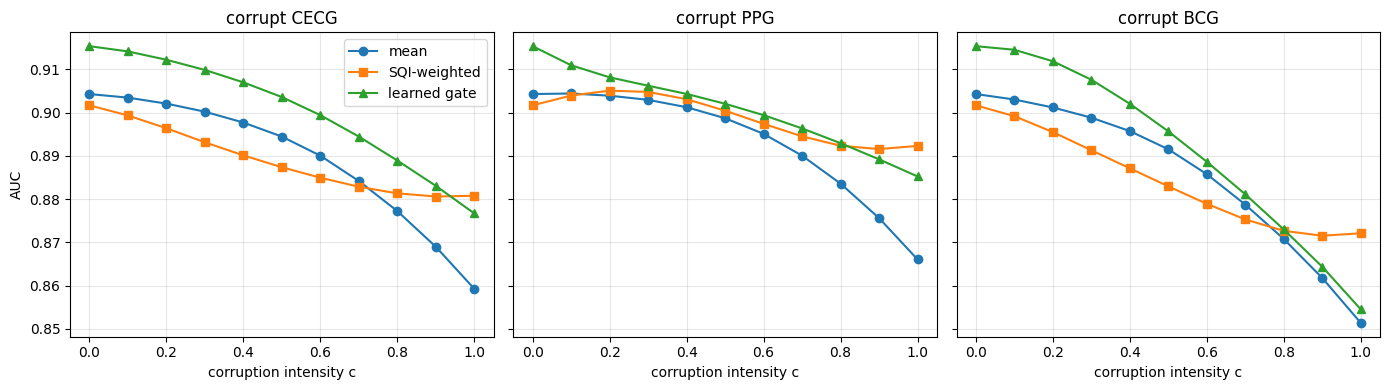

,channel,mean_at_c1,sqi_at_c1,gate_at_c1,robustness_gain_sqi,AUC_drop_mean,AUC_drop_sqi
0,cecg,0.859,0.881,0.877,0.022,0.045,0.021
1,ppg,0.866,0.892,0.885,0.026,0.038,0.009
2,bcg,0.851,0.872,0.855,0.021,0.053,0.030


robustness_gain_sqi = how much AUC the SQI weight model recovers vs the mean at a fully dead channel.


In [8]:
cs = np.linspace(0, 1, 11)
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
summary = []
for ax, midx in zip(axes, range(3)):
    am, asq, ag = [], [], []
    for c in cs:
        Pc, Cc, Xc = corrupt(P, COMP, Xsqi_clean, midx, c, frac=1.0, seed=0)
        am.append(roc_auc_score(y, mean_fuse(Pc)))
        sp, _ = sqi_weight_fuse(Pc, Cc); asq.append(roc_auc_score(y, sp))
        ag.append(roc_auc_score(y, GATE.predict_proba(Xc, Pc)))
    ax.plot(cs, am, "o-", label="mean"); ax.plot(cs, asq, "s-", label="SQI-weighted")
    ax.plot(cs, ag, "^-", label="learned gate")
    ax.set_title(f"corrupt {MODALITIES[midx].upper()}"); ax.set_xlabel("corruption intensity c"); ax.grid(alpha=.3)
    summary.append(dict(channel=MODALITIES[midx],
                        mean_at_c1=round(am[-1],3), sqi_at_c1=round(asq[-1],3), gate_at_c1=round(ag[-1],3),
                        robustness_gain_sqi=round(asq[-1]-am[-1],3),
                        AUC_drop_mean=round(am[0]-am[-1],3), AUC_drop_sqi=round(asq[0]-asq[-1],3)))
axes[0].set_ylabel("AUC"); axes[0].legend(); plt.tight_layout(); plt.show()
display(pd.DataFrame(summary))
print("robustness_gain_sqi = how much AUC the SQI weight model recovers vs the mean at a fully dead channel.")


## 4 · Second view — sweep the *fraction* of corrupted windows (dead channel, `c=1`)

Fixes intensity at a dead channel and varies how often it happens. This is closer to a real recording where
artifacts hit intermittently, and gives you a "% of windows corrupted vs AUC retained" curve to report.

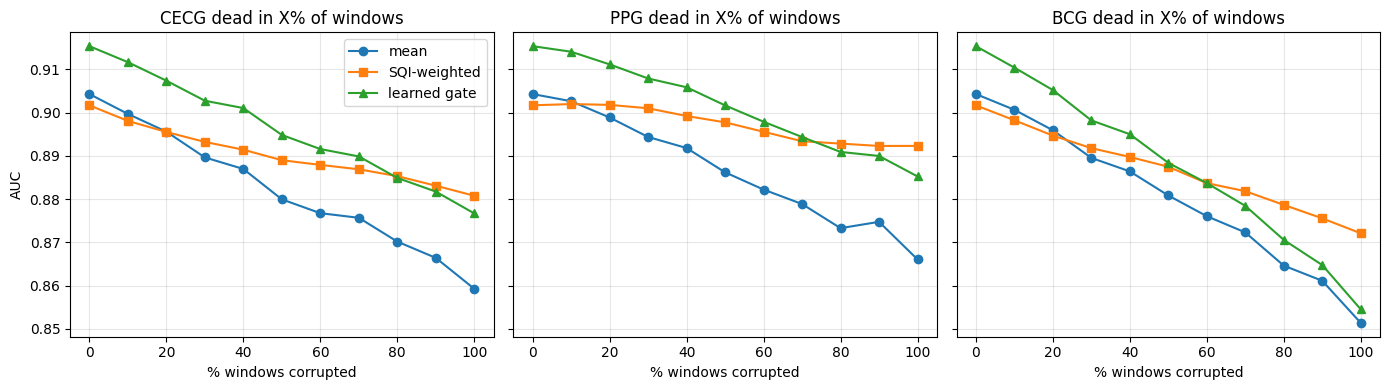

In [9]:
fracs = np.linspace(0, 1, 11)
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, midx in zip(axes, range(3)):
    am, asq, ag = [], [], []
    for fr in fracs:
        Pc, Cc, Xc = corrupt(P, COMP, Xsqi_clean, midx, c=1.0, frac=fr, seed=0)
        am.append(roc_auc_score(y, mean_fuse(Pc)))
        sp,_ = sqi_weight_fuse(Pc, Cc); asq.append(roc_auc_score(y, sp))
        ag.append(roc_auc_score(y, GATE.predict_proba(Xc, Pc)))
    ax.plot(fracs*100, am, "o-", label="mean"); ax.plot(fracs*100, asq, "s-", label="SQI-weighted")
    ax.plot(fracs*100, ag, "^-", label="learned gate")
    ax.set_title(f"{MODALITIES[midx].upper()} dead in X% of windows")
    ax.set_xlabel("% windows corrupted"); ax.grid(alpha=.3)
axes[0].set_ylabel("AUC"); axes[0].legend(); plt.tight_layout(); plt.show()


## 5 · One summary number — robustness across all channels

Area-between-curves (SQI-weighted minus mean, integrated over the intensity sweep) is a single scalar for
"how much robustness the quality index adds." Positive = the weight model helps under artifacts. Report this
per channel plus the average.

In [10]:
def area_gain(midx):
    am, asq = [], []
    for c in cs:
        Pc, Cc, _ = corrupt(P, COMP, Xsqi_clean, midx, c, 1.0, 0)
        am.append(roc_auc_score(y, mean_fuse(Pc)))
        sp,_ = sqi_weight_fuse(Pc, Cc); asq.append(roc_auc_score(y, sp))
    _trap = np.trapezoid if hasattr(np, "trapezoid") else np.trapz   # numpy>=2 renamed trapz
    return float(_trap(np.array(asq)-np.array(am), cs))      # >0 means SQI-weighting wins under corruption
gains = {MODALITIES[m]: round(area_gain(m), 4) for m in range(3)}
print("robustness area-gain (SQI-weighted - mean), per corrupted channel:", gains)
print("average:", round(np.mean(list(gains.values())), 4))


robustness area-gain (SQI-weighted - mean), per corrupted channel: {'cecg': -0.0013, 'ppg': 0.0049, 'bcg': -0.0024}
average: 0.0004


## 6 · Upgrading to gold-standard `raw` corruption (real data)

The proxy above injects the *effect* of an artifact. The higher-fidelity version corrupts the **raw signal**
and re-runs the real extraction so the SQI responds for the right reasons. Wire this to your loader; it is
not exercised by the synthetic fallback. The pattern:

```python
import features as F, sqi as Q
from signal_loader import PatientSignals

def corrupt_raw_window(w, fs, kind="motion", snr_db=0.0, rng=None):
    rng = rng or np.random.default_rng(0); p = np.mean(np.asarray(w, float)**2)
    if kind == "motion":
        t = np.arange(len(w))/fs
        art = 0.8*np.sqrt(p)*np.sin(2*np.pi*rng.uniform(0.1, 0.5)*t)
        burst = rng.random(len(w)) < 0.02
        art[burst] += rng.normal(0, 3*np.sqrt(p), burst.sum())
    else:                                   # additive white noise at target SNR
        art = rng.normal(0, np.sqrt(p/10**(snr_db/10)), len(w))
    return np.asarray(w, float) + art

# For one (patient, win_idx, channel):
#   1) load + filter + align via PatientSignals (as extract.py does)
#   2) slice the WINDOW for that channel; w_bad = corrupt_raw_window(w, FS, ...)
#   3) re-extract THAT channel only:
#        block = (F.bcg_wavelet_feature_block(w_bad, FS, s) if s in ("bcg1","bcg2") and BCG_MODE=="wavelet"
#                 else F.signal_feature_block(w_bad, FS, s, hrv_fn=..., af_rr_fn=..., use_legacy_freq=False))
#        sq    = Q.signal_sqi(w_bad, FS, SIG_TYPE[s])     # SQI now legitimately reflects the artifact
#   4) recompute that expert's prob with the model fit on the (clean) training fold
#   5) feed into the SAME mean / SQI-weighted / gate rules and rebuild the curves of Section 3
```
The curves will look like the proxy's (that is the validation that the proxy is faithful); the difference is
that here the SQI drop is *earned* by the extractor, which is the most defensible thing to put in the thesis.

## 7 · How this satisfies the assignment

- **"at least one quality index per signal"** — the per-signal composite SQI (built from kSQI/sSQI/pSQI/
  bSQI/tSQI), one per channel.
- **"taken into account in the fusion"** — the `SQI-weighted` rule `Σ wᵢpᵢ / Σ wᵢ` and the learned gate, both
  consuming that index. This *is* your supervisor's weight-model box.
- **"thereby improves robustness against artifacts"** — Sections 3–5 are the proof: under channel
  corruption the SQI-weighted fusion retains AUC that the naive mean loses, quantified per channel and as a
  single area-gain. The clean-data tie (mean ≈ weighted) is reported honestly as the *expected* baseline;
  robustness is the axis on which the quality index demonstrably pays off.
- For the **algorithm comparison** half of the brief, swap the expert model (LR / RandomForest / SVM / MLP /
  HistGBM) and the fusion rule (mean / SQI-weighted / learned gate / error-prediction / stacking /
  intermediate-fusion) and report the grid on both clean metrics and these robustness curves.

In [11]:
bad = COMP[:, 0] <= np.quantile(COMP[:, 0], 0.10)     # real low-quality cECG windows
for name, p in [("mean", P.mean(1)),
                ("sqi-weighted", sqi_weight_fuse(P, COMP)[0]),
                ("gate", GATE.predict_proba(Xsqi_clean, P))]:
    print(f"{name:13s} bad-cECG AUC={roc_auc_score(y[bad], p[bad]):.3f}  "
          f"clean AUC={roc_auc_score(y[~bad], p[~bad]):.3f}")

mean          bad-cECG AUC=0.690  clean AUC=0.919
sqi-weighted  bad-cECG AUC=0.689  clean AUC=0.916
gate          bad-cECG AUC=0.700  clean AUC=0.929
